# Exploration de l'anonymisation Presidio

Objectif : avant d'appliquer une anonymisation Presidio sur l'ensemble du SFT et du DPO (`docs/etape1.md`), explorer ce que `AnalyzerEngine` détecte réellement sur un échantillon de chaque source, en français et en anglais, pour évaluer si les entités repérées sont de vraies données identifiantes ou du bruit.

Presidio est configuré avec deux modèles spaCy (`fr_core_news_md`, `en_core_web_md`), ajoutés comme dépendances dans `pyproject.toml`.

In [ ]:
import sys
sys.path.append("..")

import matplotlib.pyplot as plt
import pandas as pd
import random
import re
from collections import Counter, defaultdict
from dotenv import load_dotenv
from presidio_analyzer import AnalyzerEngine
from presidio_analyzer.nlp_engine import NlpEngineProvider
from scripts.extraction import load_mediqa, load_frenchmedmcqa, load_medquad, load_ultramedical_preference
from src.visualizer import create_barplot, create_heatmap

load_dotenv()

config = {
    "nlp_engine_name": "spacy",
    "models": [
        {"lang_code": "fr", "model_name": "fr_core_news_md"},
        {"lang_code": "en", "model_name": "en_core_web_md"},
    ],
}
provider = NlpEngineProvider(nlp_configuration=config)
analyzer = AnalyzerEngine(nlp_engine=provider.create_engine(), supported_languages=["fr", "en"])
print("langues supportées :", analyzer.supported_languages)

/home/rapha/ia-engineer/llm-finetuning/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


langues supportées : ['fr', 'en']


## Échantillonnage et détection

80 exemples par source (instruction + réponse, ou prompt + chosen pour le DPO), tronqués à 1000 caractères pour garder l'analyse rapide sur cette exploration. Toutes les détections sont gardées (comptage et exemples), pour que les exemples cités plus bas viennent bien de ce même passage, sans retirage.

In [2]:
rng = random.Random(42)

def texte(record):
    if "instruction" in record:
        return (record["instruction"] + "\n" + record["reponse"]).strip()
    return (record["prompt"] + "\n" + record["chosen"]).strip()

sources = {
    "mediqal": (load_mediqa(), "fr"),
    "frenchmedmcqa": (load_frenchmedmcqa(), "fr"),
    "medquad": (load_medquad(), "en"),
    "ultramedical_preference": (load_ultramedical_preference(), "en"),
}

compteurs = {}
exemples = defaultdict(list)  # (source, entity_type) -> [(texte_source, entite)]

for nom, (records, langue) in sources.items():
    compteur = Counter()
    for r in rng.sample(records, min(80, len(records))):
        t = texte(r)[:1000]
        resultats = analyzer.analyze(text=t, language=langue)
        for res in resultats:
            compteur[res.entity_type] += 1
            exemples[(nom, res.entity_type)].append((t, t[res.start:res.end]))
    compteurs[nom] = compteur
    print(f"{nom} ({langue}) :", dict(compteur))

mediqal (fr) : {'PERSON': 82, 'LOCATION': 138, 'ORGANIZATION': 50, 'URL': 8, 'DATE_TIME': 3}
frenchmedmcqa (fr) : {'LOCATION': 86, 'ORGANIZATION': 31, 'PERSON': 55}
medquad (en) : {'ORGANIZATION': 153, 'LOCATION': 22, 'NRP': 9, 'URL': 4, 'PERSON': 53, 'DATE_TIME': 31, 'PHONE_NUMBER': 1, 'US_SSN': 1}
ultramedical_preference (en) : {'PERSON': 82, 'ORGANIZATION': 139, 'NRP': 7, 'DATE_TIME': 108, 'LOCATION': 17, 'URL': 4, 'US_DRIVER_LICENSE': 21}


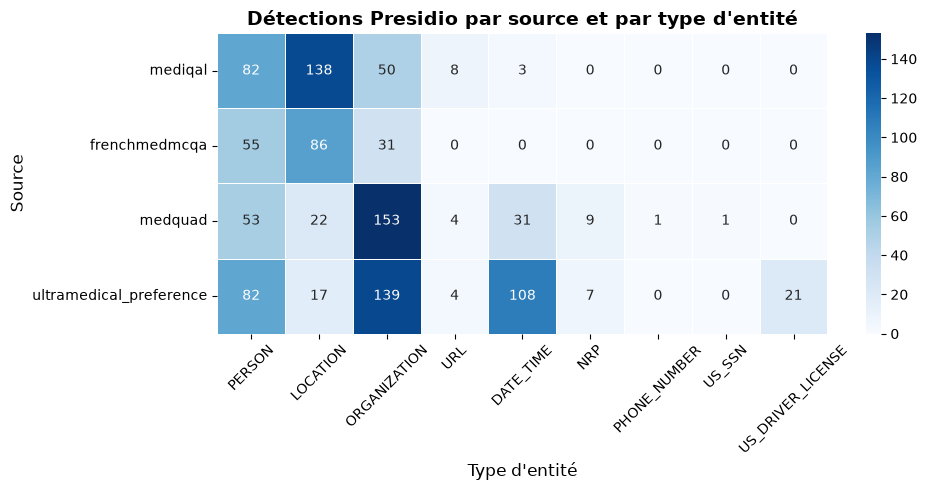

In [3]:
entites_df = pd.DataFrame(compteurs).fillna(0).T

fig, ax = plt.subplots(figsize=(10, 5))
create_heatmap(
    entites_df, ax, fmt=".0f", cmap="Blues",
    title="Détections Presidio par source et par type d'entité",
    xlabel="Type d'entité", ylabel="Source",
)
plt.tight_layout()
plt.show()

PERSON, LOCATION et ORGANIZATION dominent largement, dans les quatre sources. Avant de conclure à de vraies données identifiantes, il faut regarder ce que ces entités contiennent réellement.

## Examen qualitatif : PERSON, LOCATION, ORGANIZATION

Le texte médical est truffé de vocabulaire clinique que le modèle de NER généraliste confond avec des noms propres : symptômes, examens, éponymes de maladies (noms de médecins historiques attachés à un syndrome). Quelques exemples pris dans l'échantillon MediQAl (français) :

In [4]:
for t, entite in exemples[("mediqal", "PERSON")][:10]:
    print(repr(entite)) 

'Translocations'
'malsagrégation méiotique'
'Jean X.'
'Jean X.'
'Bactériologique'
'mL\n '
'H.'
'Sg Hémoglobine'
'Gazométrie\n Sg-'
'Biochimie\n Se-'


Certains de ces exemples ne sont pas du vocabulaire médical mal classé, mais bien des noms de patients (convention classique des cas cliniques d'examen français : prénom + initiale du nom, par exemple « Brigitte V. » ou « Jean X. »). Recherche systématique de ce motif dans les détections PERSON de MediQAl :

In [5]:
motif_nom = re.compile(r"^[A-ZÉÈÀÂÎÔÛ][a-zàâéèêëîïôûùç]+ [A-Z]\.?$")
candidats = [entite for _, entite in exemples[("mediqal", "PERSON")] if motif_nom.match(entite.strip())]
print("candidats prénom + initiale :", candidats)

for t, entite in exemples[("mediqal", "PERSON")]:
    if entite.strip() == candidats[0]:
        print()
        print(t[:250].replace("\n", " "), "...")
        break

candidats prénom + initiale : ['Jean X.', 'Jean X.', 'Mme Y.', 'Mme C', 'Mr D.', 'Madame C.', 'Mme C', 'Mme B.', 'Madame C.', 'Mme T.', 'Mme T.', 'Mme T', 'Madame H', 'Monsieur X.', 'Mr X', 'Mme C.', 'Brigitte V.', 'Brigitte V.', 'Paula B.', 'Monsieur X.', 'Madame P.']

Cas clinique : Monsieur Jean X. présente depuis 3 jours une urétrite et une dysurie modérée. Ces manifestations se sont développées 15 jours après qu’il ait eu des relations sexuelles avec une nouvelle partenaire. Il a reçu, à ce jour, aucun traiteme ...


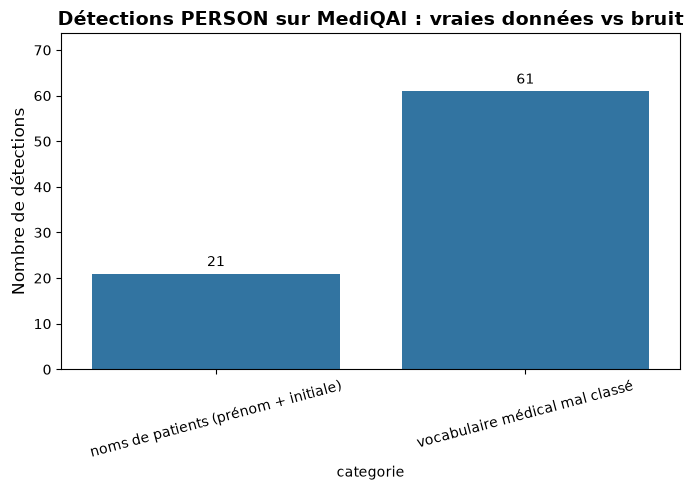

In [6]:
total_person_mediqal = len(exemples[("mediqal", "PERSON")])
vrais_positifs = len(candidats)

vp_fp_df = pd.DataFrame([
    {"categorie": "noms de patients (prénom + initiale)", "n": vrais_positifs},
    {"categorie": "vocabulaire médical mal classé", "n": total_person_mediqal - vrais_positifs},
])

fig, ax = plt.subplots(figsize=(7, 5))
create_barplot(
    vp_fp_df, ax, x="categorie", y="n",
    title="Détections PERSON sur MediQAl : vraies données vs bruit",
    xlabel="", ylabel="Nombre de détections",
    fmt="{:.0f}", xrotation=15,
)
plt.tight_layout()
plt.show()

Ce n'est pas un cas isolé : sur les 21 candidats trouvés par ce motif (Jean X., Mme Y., Mr D., Madame C., Brigitte V., Paula B., Madame P.…), MediQAl utilise systématiquement cette convention pour nommer les patients dans ses cas cliniques rédigés. Contrairement au reste des détections PERSON de cette source (vocabulaire médical mal classé), ce sont de vraies données à anonymiser.

Côté anglais, sur UltraMedical-Preference : les éponymes de syndromes, les noms de molécules et les lettres d'options de QCM sont classés PERSON, sans qu'aucun n'identifie une personne réelle.

In [7]:
for t, entite in exemples[("ultramedical_preference", "PERSON")][:10]:
    print(repr(entite))

'A. Metronidazole -'
'B. Chloroquine'
'C. Diloxanide'
'CRISPR'
'CRISPR'
'CRISPR'
'CRISPR'
'A. Angiosarcoma'
'Angiosarcoma'
'A. McNaughten'


## Examen qualitatif : DATE_TIME

Sur UltraMedical-Preference, DATE_TIME est un des types les plus fréquents. À vérifier : ce sont surtout des âges de patients dans les vignettes cliniques (« 63-year-old ») ou des durées de symptômes, pas des dates de naissance ni des dates calendaires précises.

In [8]:
for t, entite in exemples[("ultramedical_preference", "DATE_TIME")][:15]:
    print(repr(entite))

'50-year-old'
'March 2013'
'60 minutes'
'20-30 minutes'
'58-year-old'
'68-year-old'
'68-year-old'
'6-month-old'
'57-year-old'
'55-year-old'
'32-year-old'
'10weeks ago'
'daily'
'daily'
'3 days'


Confirmé : ce sont des âges ou des durées cliniques, des informations nécessaires au raisonnement de triage, pas des dates identifiantes.

## Examen qualitatif : les recognizers à motif (URL, PHONE_NUMBER, US_DRIVER_LICENSE)

Ces recognizers reposent sur des expressions régulières, donc en principe plus fiables que le NER généraliste. À vérifier quand même.

In [9]:
for (nom, type_), occurrences in exemples.items():
    if type_ in ("URL", "US_DRIVER_LICENSE", "PHONE_NUMBER"):
        print(f"--- {type_} ({nom}) ---")
        for t, entite in occurrences[:8]:
            print(" ", repr(entite))

--- URL (mediqal) ---
  'courantes.So'
  'charcutier.Il'
  'charcutier.Il'
  'orteil.Il'
  'naval.Il'
  'decin.La'
  'droit.La'
  'digital.NF'
--- URL (medquad) ---
  'www.nia.nih.gov/alzheimers/publication/caring-person-alzheimers-disease'
  'MayoClinic.com'
  'http://www.nidcr.nih.gov/Research/NIDCRLaboratories/'
  'default.ht'
--- PHONE_NUMBER (medquad) ---
  '301-435-8528'
--- URL (ultramedical_preference) ---
  '..ki'
  'Dr.ar'
  'treatment.Tel'
  '2010.Sh'
--- US_DRIVER_LICENSE (ultramedical_preference) ---
  'SP110'
  'B3'
  'B12'
  'A375'
  'WM115'
  'm3'
  'B19'
  'B19'


Deux cas de figure très différents :

- Sur MediQAl et UltraMedical-Preference, `URL` capture des passages où il manque un espace après un point (le motif regex l'interprète comme un nom de domaine), et `US_DRIVER_LICENSE` capture des lettres d'options de QCM ou des noms de lignées cellulaires. Ce sont des artefacts, pas des données identifiantes.
- Sur MedQuAD en revanche, `URL` et `PHONE_NUMBER` détectent de vraies URLs et un vrai numéro de téléphone. Mais en contexte, ce sont des ressources publiques citées dans les réponses (sites et numéros d'organismes de santé publique comme le NIH), pas les coordonnées d'un patient. Anonymiser ces liens retirerait une information utile à l'utilisateur final, sans aucun bénéfice RGPD.

## Synthèse

Sur les 4 sources (80 exemples chacune, plusieurs centaines d'entités détectées au total), la quasi-totalité des détections sont du bruit ou des informations non identifiantes :

- **PERSON / LOCATION / ORGANIZATION** (le gros du volume) : vocabulaire clinique et éponymes de syndromes confondus avec des noms propres, dans les deux langues.
- **DATE_TIME** : âges de patients et durées cliniques, pas des dates identifiantes.
- **URL / PHONE_NUMBER / US_DRIVER_LICENSE** : soit des artefacts de mise en forme (espace manquant après un point, lettres d'options de QCM), soit de vraies coordonnées mais appartenant à des organismes publics cités en référence, pas à des patients.

Un vrai signal malgré tout : MediQAl utilise systématiquement la convention prénom + initiale pour nommer les patients dans ses cas cliniques rédigés (21 détections sur ce motif dans l'échantillon). Une source de vraies données à anonymiser, contrairement aux trois autres.

Ce que ça implique pour la suite : appliquer l'anonymisation par défaut de Presidio telle quelle (remplacer toute détection PERSON/LOCATION/ORGANIZATION/DATE_TIME/URL/PHONE_NUMBER) détruirait une grande partie du contenu clinique et des ressources utiles à l'entraînement, pour un gain RGPD quasi nul en dehors de MediQAl.

Point à trancher avec le mentor (voir `docs/decisions.md`) : quelle stratégie adopter, par exemple restreindre l'anonymisation systématique aux cas cliniques rédigés de MediQAl (seule source concernée par des noms de patients), plutôt qu'un passage NER généralisé sur les 4 sources qui ferait plus de dégâts que de bien.

## Anonymisation complémentaire : email, téléphone, numéro de sécu et Améli

Au delà des noms de patients traités plus haut, la RGPD couvre aussi les identifiants directs : email, téléphone, et surtout le numéro de sécurité sociale (NIR). C'est l'identifiant le plus sensible qu'on puisse trouver dans un contexte médical, unique et attribué à vie, donc à traiter avec au moins autant de rigueur qu'un nom de patient. Presidio a des recognizers par défaut pour EMAIL_ADDRESS et PHONE_NUMBER, mais pas pour le NIR français ni pour le numéro Améli (même format). Il faut donc écrire ce motif à la main, et d'abord vérifier qu'il détecte bien un vrai NIR avant de conclure quoi que ce soit sur son absence dans le corpus : un résultat à zéro ne prouve rien si le motif ne matche jamais.

In [10]:
MOTIF_NIR = re.compile(
    r"\b[12]\s?\d{2}\s?(?:0[1-9]|1[0-2]|20)\s?(?:2[AB]|\d{2})\s?\d{3}\s?\d{3}(?:\s?\d{2})?\b"
)

cas_synthetiques = [
    ("Le patient indique son numéro de sécurité sociale : 1 85 03 75 108 121 45.", True),
    ("Numéro Améli : 285037510812145", True),
    ("NIR 2 90 07 2A 063 178 26 pour la prise en charge.", True),
    ("Référence dossier RH-2024-0912 et code postal 75008 pour information.", False),
]

for texte, attendu in cas_synthetiques:
    trouve = bool(MOTIF_NIR.search(texte))
    statut = "OK" if trouve == attendu else "ECHEC"
    print(f"{statut} (attendu={attendu}, trouvé={trouve}) : {texte}")

OK (attendu=True, trouvé=True) : Le patient indique son numéro de sécurité sociale : 1 85 03 75 108 121 45.
OK (attendu=True, trouvé=True) : Numéro Améli : 285037510812145
OK (attendu=True, trouvé=True) : NIR 2 90 07 2A 063 178 26 pour la prise en charge.
OK (attendu=False, trouvé=False) : Référence dossier RH-2024-0912 et code postal 75008 pour information.


Le motif détecte bien les NIR/Améli synthétiques, sans se déclencher sur une référence de dossier ou un code postal. Recherche maintenant sur le corpus réel **complet** (pas un échantillon comme plus haut : il s'agit de vérifier une absence, pas d'explorer). On en profite pour recompter email et téléphone sur l'ensemble des sources, pas seulement l'échantillon de 80 vu plus haut.

In [11]:
MOTIF_EMAIL = re.compile(r"[\w.+-]+@[\w-]+\.[\w.-]+")
MOTIF_TELEPHONE_FR = re.compile(r"(?:\+33[\s.-]?|0)[1-9](?:[\s.-]?\d{2}){4}")


def textes(record):
    if "instruction" in record:
        return [record["instruction"], record["reponse"]]
    return [record["prompt"], record["chosen"], record["rejected"]]


resultats_pii = {}
for nom, (records, _) in sources.items():
    compteur = Counter()
    for record in records:
        for t in textes(record):
            compteur["nir_ameli"] += len(MOTIF_NIR.findall(t))
            compteur["email"] += len(MOTIF_EMAIL.findall(t))
            compteur["telephone_fr"] += len(MOTIF_TELEPHONE_FR.findall(t))
    resultats_pii[nom] = dict(compteur)
    print(f"{nom} ({len(records)} exemples) :", dict(compteur))

mediqal (4969 exemples) : {'nir_ameli': 0, 'email': 0, 'telephone_fr': 0}
frenchmedmcqa (1080 exemples) : {'nir_ameli': 0, 'email': 0, 'telephone_fr': 0}
medquad (16407 exemples) : {'nir_ameli': 0, 'email': 13, 'telephone_fr': 0}
ultramedical_preference (110753 exemples) : {'nir_ameli': 0, 'email': 28, 'telephone_fr': 9}


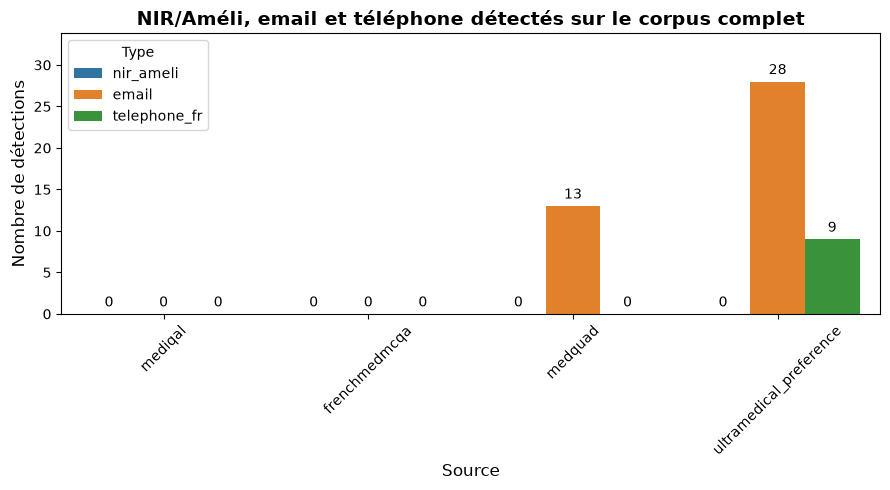

In [12]:
pii_df = pd.DataFrame(
    [{"source": nom, "type": type_, "n": n} for nom, compte in resultats_pii.items() for type_, n in compte.items()]
)

fig, ax = plt.subplots(figsize=(9, 5))
create_barplot(
    pii_df, ax, x="source", y="n", hue="type",
    title="NIR/Améli, email et téléphone détectés sur le corpus complet",
    xlabel="Source", ylabel="Nombre de détections",
    show_legend=True, legend_title="Type", fmt="{:.0f}",
)
plt.tight_layout()
plt.show()

Confirmé sur le corpus complet : zéro numéro de sécurité sociale ou Améli, dans les 4 sources. Le motif recherché est validé sur des cas synthétiques (cellule plus haut), donc cette absence est un vrai résultat, pas un motif défaillant. Pas besoin de recognizer Presidio personnalisé pour ce point.

Email et téléphone existent en revanche, concentrés sur deux sources anglaises :

- **MedQuAD** : uniquement des adresses institutionnelles (NIH, associations de patients type ATA ou RESNA), citées comme ressources publiques dans les réponses. Même logique que pour URL et PHONE_NUMBER plus haut : ce ne sont pas des données de patients, pas la peine d'y toucher.
- **UltraMedical-Preference** : mélange d'adresses institutionnelles et d'une poignée de vrais contacts personnels (emails et numéros de téléphone laissés par des patients ou leurs proches dans des questions de forum, avec parfois un nom associé). C'est la seule source qui justifie une anonymisation.

Décision : appliquer les recognizers Presidio par défaut (`EMAIL_ADDRESS`, `PHONE_NUMBER`) sur UltraMedical-Preference uniquement. Contrairement à PERSON, ce sont des recognizers à base de regex, donc pas le problème de faux positifs rencontré plus haut avec le NER généraliste. spaCy NER en complément reste une piste d'amélioration pour plus tard si on veut couvrir d'autres types de données moins structurées (voir `docs/ameliorations_potentielles.md`), pas nécessaire ici vu le faible volume concerné. Implémenté dans `scripts/anonymisation.py` (`anonymize_ultramedical_preference`).